# Agent的上下文工程

## overview 

在构建 Agent 或者 任何LLM应用的时候，难点一般在于使其足够可靠。虽然一些应用在原型的时候可以正常工作，但是经常会在真实使用中失败

为什么 Agent 会任务失败？

当 Agent 任务失败时，通常是因为Agent内部的LLM调用采取了错误的行为，没有按照预期的去做。 LLM 失败的原因来两种：
1. 底层LLM能力不足
2. 没有传递正确的 上下文 给LLM

一般来说都是第二个惹的祸，导致Agent变得不可靠

上下文工程（Context Engineering）就是 为 `LLM` 提供正确的 **信息、工具，并且按照正确的格式完成任务** 的 **上下文**。 “正确”的上下文是Agent变得更加可靠的首要任务，Langchain的Agent抽象设计，为了促进上下文工程



## Context 是什么？

> 关于上下文的相关概念

上下文工程是构建动态系统的实践，这些系统能够提供 **合适的信息** 和 **工具** ，以正确的 **格式** ，使 AI 应用能够完成任务。上下文可以通过两个关键维度来描述，一个是可变性、一个是按照生命周期



1. 可变性
   - Static Context：静态上下文，在执行期间不变的数据，比如说用户元数据、数据库连接、工具
   - Dynamic Context：动态上下文，在执行期间不断变化的数据，比如说对话历史记录、中间结果、工具调用观察结果
2. 生命周期
   - Runtime Context：运行时上下文，仅限在单个运行或调用期间存在的
   - Cross-conversation：跨对话上下文，在多个对话中持续存在的数据

> 运行时上下文（Runtime Context）指的是本地的上下文，也就是代码运行时所需的数据和依赖项，运行时上下文不是指：
> 1. LLM 的上下文、也就是传递给大模型的所有提示数据（消息列表、skills、mcp等等数据）
> 2. 上下文窗口，也就是可以传递给模型的最大tokens数量
>
> Runtime Context 是一种依赖注入形式，可以用于优化传入给LLM的上下文。它允许在运行时而不是硬编码的方式向 工具 和 节点 提供依赖项（比如说数据库连接、用户ID），可以使用运行时上下文中的用户元数据来获取用户偏好，并且将他们写入LLM的上下文窗口


langgraph提供了三种管理上下文的方式，结合了可变性和生命周期两个维度

| Context type 上下文类型 | Description 描述 | Mutability 可变性 | Lifetime 生命周期 | Access method 访问方法 |
| --- | --- | --- | --- | --- |
| [**Static runtime context 静态运行时上下文**](https://docs.langchain.com/oss/python/concepts/context#static-runtime-context) | User metadata, tools, db connections passed at startup   在启动时传递的用户元数据、工具、数据库连接 | Static 静态 | Single run 单次运行 |   传入 `context` 参数到 `invoke` / `stream` |
| [**Dynamic runtime context (state)   动态运行时上下文（状态）**](https://docs.langchain.com/oss/python/concepts/context#dynamic-runtime-context-state) | Mutable data that evolves during a single run   在单次运行期间演变的可变数据 | Dynamic 动态 | Single run 单次运行 | LangGraph state object LangGraph 状态对象 |
| [**Dynamic cross-conversation context (store)   动态跨对话上下文（存储）**](https://docs.langchain.com/oss/python/concepts/context#dynamic-cross-conversation-context-store) | Persistent data shared across conversations   跨对话持久共享数据 | Dynamic 动态 | Cross-conversation 跨对话 | LangGraph store LangGraph 存储 |





【一句话来说】

> langgraph里面有三种管理上下文的方式，一种是静态的上下文，在启动时传递用户元数据、工具、数据库连接，这些在单次运行期间是不会变化的，通过 context 参数传递给 invoke / stream；第二种是单次运行的State（状态），在单次运行期间可变的数据，比如说消息列表，或者自定义的字段（权限变化）；第三种是跨对话的Store，跨对话持久共享数据。

### Static Runtime Context

静态运行时上下文代表不可变数据，如用户元数据、工具和数据库连接，这些数据通过 context 参数在运行开始时传递给应用程序 / invoke / stream 。这些数据在执行过程中不会改变。

我们可以通过 `@dataclass`、Pydantic、TypedDict 来定义 Context 的格式

### Dynamic Runtime Context -- State

动态运行时上下文表示在单次运行期间可以演变的可变数据，并通过 **LangGraph State** 对象进行管理。这包括 **对话历史记录、中间结果以及从工具或 LLM 输出中派生的值** 。在 LangGraph 中，State 对象在运行期间充当短期记忆。 State -> 短期记忆

State也可以被Agent的Tools访问，这些Tools可以根据需要访问和修改State中的数据

In [ ]:
# ? 在 Agent 中使用 State
from langchain.agents import create_agent
from langchain.agents.middleware import dynamic_prompt, ModelRequest
from langchain.agents import AgentState

In [1]:
from langchain_openai import ChatOpenAI
import os


def get_model():
    """获取聊天模型实例"""
    return ChatOpenAI(
        model="Qwen/Qwen2.5-7B-Instruct",
        base_url="https://api.siliconflow.cn/v1",
        api_key=os.environ.get("SILICONFLOW_API_KEY"),
        temperature=0.2,
    )


llm = get_model()
llm

ChatOpenAI(profile={}, client=<openai.resources.chat.completions.completions.Completions object at 0x000002018D9C7510>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x000002018DF02310>, root_client=<openai.OpenAI object at 0x000002018D924050>, root_async_client=<openai.AsyncOpenAI object at 0x000002018DF01790>, model_name='Qwen/Qwen2.5-7B-Instruct', temperature=0.2, model_kwargs={}, openai_api_key=SecretStr('**********'), openai_api_base='https://api.siliconflow.cn/v1')

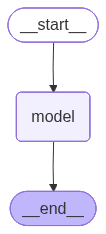

In [ ]:
# 定义 Context Schema
# 通过继承AgentState类，我们可以定义一个自定义的AgentState类，用于存储自定义的上下文信息


class CustomAgentState(AgentState):
    user_name: str


@dynamic_prompt
def personalized_prompt(request: ModelRequest) -> str:
    # ? 从 request.state 中获取 user_name 然后组装到系统提示词里
    user_name = request.state.get("user_name", "User")
    return f"你服务的人叫做：{user_name}！"


agent = create_agent(
    model=llm,
    tools=[],
    state_schema=CustomAgentState,  # 这个Agent的State格式
    middleware=[personalized_prompt],
)
agent

In [ ]:
agent.invoke({"messages": "你好", "user_name": "Chasen"})["messages"][-1].content

'你好！很高兴为你提供帮助，Chasen。你需要了解或解决些什么问题呢？'

### Dynamic cross-conversation context -- Store

动态跨对话上下文代表持久且可变的数据，这些数据跨越多个对话或会话，并通过 LangGraph Store 进行管理。这包括用户资料、偏好和历史交互。LangGraph Store 充当跨多次运行的 **长时记忆** 。这可用于读取或更新持久事实（例如，用户资料、偏好、先前的交互）。

## The Agent Loop
典型的 Agent Loop 主要包括两个步骤组成：
1. Model Call：调用模型，使用提示词或者工具调用 LLM，返回响应或工具的请求
2. Tool Execution：执行LLM请求的工具，返回工具的响应

这个循环会一直持续，直到LLM决定结束

## 什么是可以控制的？
为了构建可靠的Agent系统，需要控制Agent Loop 的每一步以及步骤之间的发生情况

首先来看可控制的Context类型：

- Model Context：模型上下文，可以控制模型调用中包含什么，指令、历史消息、工具、响应格式。这个上下文是瞬时性的，也就是在调用模型的时候传递给模型的数据
- Tool Context：工具上下文，可以控制哪些工具可以访问和产生，读取或写入State、Store、Runtime Context。这个变化是持久化的
- Life-cycle Context：生命周期上下文，可以控制模型和工具调用之间会发生什么，比如说摘要、护栏、日志记录等等；它让你能够在智能体运行的不同阶段插入自定义逻辑，通过中间件来实现

【瞬时上下文和持久上下文？】
- 瞬时：一个调用中大模型看到的内容，可以修改信息、工具或提示，而不需要修改保存的State
- 持久：跨回合保存的内容，生命周期钩子和工具写入会永久修改此内容

## 数据源（Data Sources）
在此过程中，Agent可访问（读写）的数据源包括：
- Runtime Context：运行时上下文也叫做 **静态配置** ，在对话范围内一直存在且不会改变；比如说用户ID、API密钥、数据库连接、权限、环境设置
- State：也叫做短期记忆，在对话范围内存在但是可以改变；比如说当前消息、上传的文件、认证状态、工具结果等
- Store：也叫做长期记忆，可以跨对话存在；比如说用户的偏好、提取的洞察、记忆、历史数据等


## 工作原理
Langchain的 `Middleware` 是使得 Langchain 的开发者能够实现上下文工程的技术机制

中间件允许钩入Agent的生命周期中的任何步骤，并且：
- 更新上下文
- 跳转到Agent生命周期的不同步骤

使用中间件是最频繁的作为Context Engineering的一种手段

## Model Context

可以控制每次模型调用中输入的内容 --> 指令、可用工具、使用哪个模型以及输出格式。这些决策直接影响了可靠性和成本

模型上下文囊括的内容有:

- System Prompt：开发者向LLM设定的 **基础指令** ，用于引导模型的行为
- Messages：发送给LLM的完整消息列表
- Tools：Agent可以访问以 **执行操作** 的工具。
- Model：实际调用的模型，包括配置
- Response Format：模型最终响应的Schema（模式/格式）

这些所有类型的模型上下文都可以从State（短期）、Store（长期）或者Runtime Context（静态配置）中获取

【扩展：Schema应该翻译成什么？】
Schema（模式）是用于定义Format（格式）的工具。格式是数据呈现或组织的方式、布局或约定。例如，JSON格式、XML格式、CSV格式等。Schema是数据结构的正式定义，包括字段名称、类型、约束和描述。

| 概念 | 英文 | 中文翻译 | 核心含义 | 在文档中的体现 |
| --- | --- | --- | --- | --- |
| Format | Format | 格式 | 数据呈现或组织的方式、布局或约定。 | 章节标题“Response format”指的是模型输出的整体形式要求。 |
| Schema | Schema | 模式、架构、纲要 | 数据结构的正式定义，包括字段名称、类型、约束和描述。 | 代码中定义的CustomerSupportTicket类，用Field指定每个字段的描述，这就是一个Schema。 |



### System Prompt
系统提示设定了 LLM 的行为和能力。不同的用户、上下文或对话阶段需要不同的指令。成功的代理会参考记忆、偏好和配置，为当前对话状态提供正确的指令。



#### 访问State
从状态中访问消息计数或对话上下文的示例代码

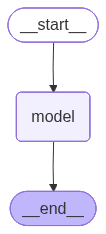

In [ ]:
from langchain.agents import create_agent
from langchain.agents.middleware import dynamic_prompt, ModelRequest


# ? 中间件传入的参数都是 request 和 handler
@dynamic_prompt
def state_aware_prompt(request: ModelRequest) -> str:
    # request.messages is a shortcut for request.state["messages"]
    message_count = len(request.messages)

    base = "You are a helpful assistant."

    if message_count > 10:
        base += "\nThis is a long conversation - be extra concise."

    return base


agent = create_agent(model=llm, tools=[], middleware=[state_aware_prompt])
agent

#### 访问Store
从Store中访问用户偏好

In [ ]:
from dataclasses import dataclass
from langchain.agents import create_agent
from langchain.agents.middleware import dynamic_prompt, ModelRequest
from langgraph.store.memory import InMemoryStore

# 定义一个Store的Schema


@dataclass
class Context:
    user_id: str
    user_name: str


#! 一般使用TypedDict来定义Store的Schema
# from typing import TypedDict
# class UserPreferences(TypedDict):
#     communication_style: str = "balanced"


@dynamic_prompt
def store_aware_prompt(request: ModelRequest) -> str:
    user_id = request.runtime.context.user_id
    # 为了查询Store中的用户偏好，需要从Runtime中获取user_id

    # Read from Store: get user preferences
    store = request.runtime.store  # 获取当前的Store
    user_prefs = store.get(("preferences",), user_id)
    # 获取命名空间("preferences",)下的user_id对应的值

    base = "You are a helpful assistant."

    if user_prefs:
        style = user_prefs.value.get("communication_style", "balanced")
        base += f"\nUser prefers {style} responses."

    return base

【扩展：request是个啥东东？？】

```python
@dataclass(init=False)
class ModelRequest(Generic[ContextT]):
    """Model request information for the agent.

    Type Parameters:
        ContextT: The type of the runtime context. Defaults to `None` if not specified.
    """

    model: BaseChatModel
    messages: list[AnyMessage]  # excluding system message
    system_message: SystemMessage | None
    tool_choice: Any | None
    tools: list[BaseTool | dict[str, Any]]
    response_format: ResponseFormat[Any] | None
    state: AgentState[Any]
    runtime: Runtime[ContextT]
    model_settings: dict[str, Any] = field(default_factory=dict)
```

ModelRequest是一个数据类，用于存储模型请求的信息。可以通过这个来在中间件中访问 State 和 Runtime 中的信息。

#### 访问Runtime Context

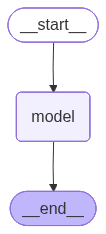

In [ ]:
from dataclasses import dataclass
from langchain.agents import create_agent
from langchain.agents.middleware import dynamic_prompt, ModelRequest


@dataclass
class CustomContext:
    user_role: str
    deployment_env: str


@dynamic_prompt
def context_aware_prompt(request: ModelRequest) -> str:
    # Read from Runtime Context: user role and environment
    user_role = request.runtime.context.user_role
    env = request.runtime.context.deployment_env

    base = "You are a helpful assistant."

    if user_role == "admin":
        base += "\nYou have admin access. You can perform all operations."
    elif user_role == "viewer":
        base += "\nYou have read-only access. Guide users to read operations only."

    if env == "production":
        base += "\nBe extra careful with any data modifications."

    return base


agent = create_agent(
    model=llm, tools=[], middleware=[context_aware_prompt], context_schema=CustomContext
)

agent

- State — 字典形式，整个运行周期的状态共享
- Store — 命名空间 + 键值对，跨会话持久化存储
- 运行时上下文（context） — 也是字典，用于传递临时信息

### Messages 消息
消息构成了发送给 LLM 的 **Prompt** 。管理消息内容至关重要，以确保 LLM 能够获得正确信息从而做出良好响应。

#### State
在当前查询中，从State中注入上传的文件的上下文


In [ ]:
from langchain.agents import create_agent
from langchain.agents.middleware import wrap_model_call, ModelRequest, ModelResponse
from typing import Callable


@wrap_model_call  # 包括模型调用时
def inject_file_context(
    request: ModelRequest, handler: Callable[[ModelRequest], ModelResponse]
) -> ModelResponse:
    """Inject context about files user has uploaded this session."""
    # 注入文件上下文到Prompt然后发送给LLM
    # wrap_model_call
    # Read from State: get uploaded files metadata
    uploaded_files = request.state.get("uploaded_files", [])

    if uploaded_files:
        # Build context about available files
        file_descriptions = []
        for file in uploaded_files:
            file_descriptions.append(
                f"- {file['name']} ({file['type']}): {file['summary']}"
            )

        file_context = f"""Files you have access to in this conversation:
{chr(10).join(file_descriptions)}

Reference these files when answering questions."""

        # Inject file context before recent messages
        messages = [
            *request.messages,  # 本来的消息列表
            {"role": "user", "content": file_context},  # 注入文件上下文
        ]
        request = request.override(messages=messages)

    return handler(request)


agent = create_agent(model=llm, tools=[], middleware=[inject_file_context])

#### 访问Store
通过中间件中的 request.runtime.store 获取当前的Store，然后注入到消息列表中

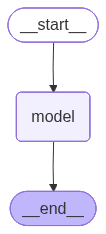

In [ ]:
from langchain.agents import create_agent
from dataclasses import dataclass
from langchain.agents.middleware import wrap_model_call, ModelRequest, ModelResponse
from typing import Callable
from langgraph.store.memory import InMemoryStore


@dataclass
class CustomContext:
    user_id: str


# 通过中间件注入写作风格


@wrap_model_call
def inject_writing_style(
    request: ModelRequest, handler: Callable[[ModelRequest], ModelResponse]
) -> ModelResponse:
    """通过读取 request.runtime.store 中的用户偏好来注入写作风格上下文到Prompt中

    Args:
        request (ModelRequest): 自动注入的模型请求
        handler (Callable[[ModelRequest], ModelResponse]): 向后传递的处理函数

    Returns:
        ModelResponse: 处理后的模型响应
    """
    # 首先获取user_id来提供给Store去查询
    user_id = request.runtime.context.user_id

    # 获取Store实例
    store = request.runtime.store
    # (namespace, key) 命名空间 + key
    writing_style = store.get(("writing_style"), user_id)

    if writing_style:
        style = writing_style.value
        # Build style guide from stored examples
        style_context = f"""Your writing style:
- Tone: {style.get("tone", "professional")}
- Typical greeting: "{style.get("greeting", "Hi")}"
- Typical sign-off: "{style.get("sign_off", "Best")}"
- Example email you've written:
{style.get("example_email", "")}"""

    messages = [
        # 拆解以前的消息列表
        *request.messages,
        # 注入写作风格上下文
        {"role": "user", "content": style_context},
    ]
    # 重写request的messages列表，然后传递给handler继续处理
    return handler(request.override(messages=messages))


agent = create_agent(
    model=llm,
    tools=[],
    middleware=[inject_writing_style],
    context_schema=CustomContext,
    store=InMemoryStore(),
)

agent

#### Runtime Context
根据用户区域从 Runtime Context 注入合规规则

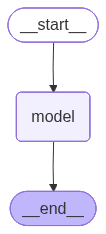

In [ ]:
from dataclasses import dataclass
from langchain.agents import create_agent
from langchain.agents.middleware import wrap_model_call, ModelRequest, ModelResponse
from typing import Callable, TypedDict


# 也可以使用TypedDict来定义
# @dataclass
# class UserContext:
#     user_jurisdiction: str
#     industry: str
#     compliance_frameworks: list[str]
class UserContext(TypedDict):
    user_jurisdiction: str
    industry: str
    compliance_frameworks: list[str]


@wrap_model_call
def inject_compliance_rules(
    request: ModelRequest, handler: Callable[[ModelRequest], ModelResponse]
) -> ModelResponse:
    """Inject compliance constraints from Runtime Context."""
    # Read from Runtime Context: get compliance requirements
    jurisdiction = request.runtime.context.user_jurisdiction
    industry = request.runtime.context.industry
    frameworks = request.runtime.context.compliance_frameworks

    # Build compliance constraints
    rules = []
    if "GDPR" in frameworks:
        rules.append("- Must obtain explicit consent before processing personal data")
        rules.append("- Users have right to data deletion")
    if "HIPAA" in frameworks:
        rules.append("- Cannot share patient health information without authorization")
        rules.append("- Must use secure, encrypted communication")
    if industry == "finance":
        rules.append("- Cannot provide financial advice without proper disclaimers")

    if rules:
        compliance_context = f"""Compliance requirements for {jurisdiction}:
{chr(10).join(rules)}"""  # chr(10) <=> \n

        # Append at end - models pay more attention to final messages
        messages = [*request.messages, {"role": "user", "content": compliance_context}]
        request = request.override(messages=messages)

    return handler(request)


agent = create_agent(
    model=llm,
    tools=[],
    middleware=[inject_compliance_rules],
    context_schema=UserContext,
)

agent

### Tools
有了工具，模型就能够和数据库、API或者外部系统交互。定义和选择模工具的方式直接影响了模型能否有效地完成任务

每个工具需要一个清晰的名字、描述、参数名称和参数描述。这些不仅仅是元数据——它们指导模型关于何时以及如何使用工具的推理。

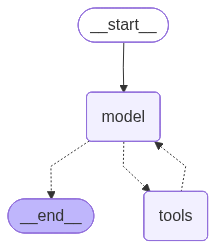

In [ ]:
from langchain.tools import tool


@tool("search_orders", parse_docstring=True, description="查询订单数据")
def search_orders(user_id: str, status: str = None, limit: int = 5) -> str:
    """查询订单数据

    Args:
        user_id (str): 用户ID
        status (str, optional): 订单状态. Defaults to None.
        limit (int, optional): 返回结果数量. Defaults to 5.

    Returns:
        str: 查询结果
    """
    pass


agent = create_agent(
    model=llm,
    tools=[search_orders],
)
agent

#### Selecting Tools
并不是每一种工具都使用每一种情况，但是工具过多也会导致占用过多的模型上下文，因为每一个Tools的docstring都会作为上下文传入给模型，所以过多的工具会导致错误的增加。而过少的工具又会限制Agent的功能。

可以通过动态工具选择，按照认证状态、用户权限、对话阶段、功能标志来调整可用的工具集

##### State
可以达到特定里程的时候，再开放一些高级工具；或者可以获取用户是否授权，没有授权就只能用 public 工具

In [ ]:
from typing import Callable  # 可调用对象：函数、方法、类
from langchain.agents.middleware import wrap_model_call, ModelRequest, ModelResponse


# ? 当模型到达一定数量的上下文的时候开放高级工具，还可以检查用户是否授权


@wrap_model_call
def state_based_tools(
    request: ModelRequest, handler: Callable[[ModelRequest], ModelResponse]
) -> ModelResponse:
    """Filter tools based on conversation state."""
    state = request.state
    is_authorized = state.get("authorized", False)
    message_count = len(state["messages"])

    # 当用户没有授权的时候只能用public工具
    if not is_authorized:
        tools = [t for t in request.tools if t.name.startswith("public_")]
        request = request.override(tools=tools)
    elif message_count < 5:
        # 小于 5 轮对话的时候不开放
        tools = [t for t in request.tools if t.name != "advanced_tool"]
        request = request.override(tools=tools)

    return handler(request)


agent = create_agent(
    model=llm,
    # tools=[public_search, private_search, advanced_search],
    middleware=[state_based_tools],
)

##### Store
可以根据用户的偏好 或 Store中 的功能标志筛选工具

In [ ]:
from dataclasses import dataclass
from langchain.agents import create_agent
from langchain.agents.middleware import wrap_model_call, ModelRequest, ModelResponse
from typing import Callable, TypedDict
from langgraph.store.memory import InMemoryStore


class UserContext(TypedDict):
    # runtime context's Schema
    user_id: str


@wrap_model_call
def store_based_tools(
    request: ModelRequest, handler: Callable[[ModelRequest], ModelResponse]
) -> ModelResponse:
    """Filter tools based on Store preferences."""
    user_id = request.runtime.context.user_id

    # Read from Store: get user's enabled features
    store = request.runtime.store  # (namespace, key)
    feature_flags = store.get(("features",), user_id)
    # get(namespace tuple, key)

    if feature_flags:
        enabled_features = feature_flags.value.get("enabled_tools", [])
        # Only include tools that are enabled for this user
        tools = [t for t in request.tools if t.name in enabled_features]
        request = request.override(tools=tools)

    return handler(request)


agent = create_agent(
    model=llm,
    # tools=[search_tool, analysis_tool, export_tool],
    middleware=[store_based_tools],
    context_schema=UserContext,
    store=InMemoryStore(),
)

##### Runtime Context
根据运行时上下文（静态配置）的用户权限来过滤工具

In [ ]:
# ? State
from dataclasses import dataclass
from langchain.agents import create_agent
from langchain.agents.middleware import wrap_model_call, ModelRequest, ModelResponse
from typing import Callable


@dataclass
class UserContext:
    user_role: str


@wrap_model_call
def context_based_tools(
    request: ModelRequest, handler: Callable[[ModelRequest], ModelResponse]
) -> ModelResponse:
    """Filter tools based on Runtime Context permissions."""
    # Read from Runtime UserContext: get user role
    user_role = request.runtime.context.user_role

    if user_role == "admin":
        # Admins get all tools
        pass
    elif user_role == "editor":
        # Editors can't delete
        tools = [t for t in request.tools if t.name != "delete_data"]
        request = request.override(tools=tools)
    else:
        # Viewers get read-only tools
        tools = [t for t in request.tools if t.name.startswith("read_")]
        request = request.override(tools=tools)

    return handler(request)


agent = create_agent(
    model=llm,
    # tools=[read_data, write_data, delete_data],
    middleware=[context_based_tools],
    context_schema=UserContext,
)

In [ ]:
# ? 通过 Store 来获取用户偏好模型并且修改要调用的模型
from dataclasses import dataclass
from langchain.agents import create_agent
from langchain.agents.middleware import wrap_model_call, ModelRequest, ModelResponse
from langchain.chat_models import init_chat_model
from typing import Callable
from langgraph.store.memory import InMemoryStore


@dataclass
class Context:
    user_id: str


# Initialize available models once
MODEL_MAP = {
    # "gpt-4.1": init_chat_model("gpt-4.1"),
    # "gpt-4.1-mini": init_chat_model("gpt-4.1-mini"),
    # "claude-sonnet": init_chat_model("claude-sonnet-4-6"),
}


@wrap_model_call
def store_based_model(
    request: ModelRequest, handler: Callable[[ModelRequest], ModelResponse]
) -> ModelResponse:
    """Select model based on Store preferences."""
    user_id = request.runtime.context.user_id

    # Read from Store: get user's preferred model
    store = request.runtime.store
    user_prefs = store.get(("preferences",), user_id)

    if user_prefs:
        preferred_model = user_prefs.value.get("preferred_model")
        if preferred_model and preferred_model in MODEL_MAP:
            request = request.override(model=MODEL_MAP[preferred_model])

    return handler(request)


agent = create_agent(
    model=llm,
    tools=[],
    middleware=[store_based_model],
    context_schema=Context,
    store=InMemoryStore(),
)

In [ ]:
# ? 根据 Runtime Context 获取成本限制和环境来选择对应的模型
from dataclasses import dataclass
from langchain.agents import create_agent
from langchain.agents.middleware import wrap_model_call, ModelRequest, ModelResponse
from langchain.chat_models import init_chat_model
from typing import Callable


@dataclass
class Context:
    cost_tier: str
    environment: str


# Initialize models once outside the middleware
# premium_model = init_chat_model("claude-sonnet-4-6")
# standard_model = init_chat_model("gpt-4.1")
# budget_model = init_chat_model("gpt-4.1-mini")
premium_model = llm
standard_model = llm
budget_model = llm


@wrap_model_call
def context_based_model(
    request: ModelRequest, handler: Callable[[ModelRequest], ModelResponse]
) -> ModelResponse:
    """Select model based on Runtime Context."""
    # Read from Runtime Context: cost tier and environment
    cost_tier = request.runtime.context.cost_tier
    environment = request.runtime.context.environment

    if environment == "production" and cost_tier == "premium":
        # Production premium users get best model
        model = premium_model
    elif cost_tier == "budget":
        # Budget tier gets efficient model
        model = budget_model
    else:
        # Standard tier
        model = standard_model

    request = request.override(model=model)

    return handler(request)


agent = create_agent(
    model=llm, tools=[], middleware=[context_based_model], context_schema=Context
)

### Response Format
结构化输出将非结构化文本转换为经过验证的结构化数据。当提取特定字段或为下游系统返回数据时，自由文本是不够的。

#### Defining Formats
定义Schema来指导Model。字段名字、类型和描述制定输出应当遵循的模式（Schema）


In [ ]:
from pydantic import BaseModel, Field


# ? 使用Pydantic可以校验格式
class CustomerSupportTicket(BaseModel):
    """Structured ticket information extracted from customer message."""

    category: str = Field(
        description="Issue category: 'billing', 'technical', 'account', or 'product'"
    )
    priority: str = Field(
        description="Urgency level: 'low', 'medium', 'high', or 'critical'"
    )
    summary: str = Field(description="One-sentence summary of the customer's issue")
    customer_sentiment: str = Field(
        description="Customer's emotional tone: 'frustrated', 'neutral', or 'satisfied'"
    )

#### 通过Middleware来选择格式
可以动态的根据用户偏好、对话阶段、角色调整来调整响应格式；在早期返回简单格式，随着复杂性的增加，返回更加详细格式；

可以在中间件中读取 State、Store、Runetime Context 来修改 `response format` 字段



### Tool Context 
工具的上下文；

工具特殊之处在于它技能读读取也能写入上下文

最基础的情况下，当工具执行的时候，会接收LLM的请求参数，返回一个工具消息。工具执行并且返回一个结果

工具还能为模型获取重要信息，使得模型能够执行和完成任务

可以说在Agent的设计中 Tools 的设计是 Agent 能力的体现


#### Read
大多数现实世界的工具不仅需要 LLM 的参数。它们需要用于数据库查询的用户 ID，用于外部服务的 API 密钥，或用于做决策的当前会话状态。工具从State、Store和Runtime Context中读取，以访问这些信息。

基本都是集成在了 `runtime` 这个参数中

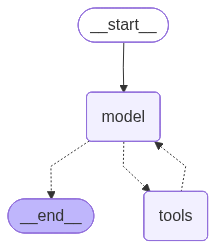

In [ ]:
# ? 从State中读取以检查当前会话信息
from langchain.tools import tool, ToolRuntime
from langchain.agents import create_agent


@tool()
def check_authentication(runtime: ToolRuntime) -> str:
    """Check if user is authenticated."""
    # Read from State: check current auth status
    current_state = runtime.state
    # runtime.state is a dict-like object
    # 类似dict的对象
    is_authenticated = current_state.get("authenticated", False)

    if is_authenticated:
        return "User is authenticated"
    else:
        return "User is not authenticated"


agent = create_agent(model=llm, tools=[check_authentication])

agent

In [ ]:
# ? 从 runtiem.store 读取以访问持久化的用户偏好设置

from dataclasses import dataclass
from langchain.tools import tool, ToolRuntime
from langchain.agents import create_agent
from langgraph.store.memory import InMemoryStore


@dataclass
class UserContext:
    user_id: str


@tool
def get_preference(preference_key: str, runtime: ToolRuntime[UserContext]) -> str:
    """Get user preference from Store."""
    user_id = runtime.context.user_id

    # Read from Store: get existing preferences
    store = runtime.store
    existing_prefs = store.get(("preferences",), user_id)

    if existing_prefs:
        value = existing_prefs.value.get(preference_key)
        return (
            f"{preference_key}: {value}"
            if value
            else f"No preference set for {preference_key}"
        )
    else:
        return "No preferences found"


agent = create_agent(
    model=llm, tools=[get_preference], context_schema=UserContext, store=InMemoryStore()
)

In [ ]:
# ? 从运行时上下文中读取配置，如 API 密钥和用户 ID
from dataclasses import dataclass
from langchain.tools import tool, ToolRuntime
from langchain.agents import create_agent


@dataclass
class Context:
    user_id: str
    api_key: str  # API_KEY
    db_connection: str  # 数据库连接


@tool
def fetch_user_data(
    query: str,
    runtime: ToolRuntime[Context],  # 这里可以填入泛型, 可以获得类型提示
) -> str:
    """Fetch data using Runtime Context configuration."""
    # Read from Runtime Context: get API key and DB connection
    user_id = runtime.context.user_id
    api_key = runtime.context.api_key
    db_connection = runtime.context.db_connection

    # Use configuration to fetch data
    # results = perform_database_query(db_connection, query, api_key)
    results = []

    return f"Found {len(results)} results for user {user_id}"


agent = create_agent(model=llm, tools=[fetch_user_data], context_schema=Context)

# # Invoke with runtime context
# result = agent.invoke(
#     {"messages": [{"role": "user", "content": "Get my data"}]},
#     context=Context(
#         user_id="user_123",
#         api_key="sk-...",
#         db_connection="postgresql://..."
#     )
# )

#### Writes
工具的结果可用于帮助Agent执行给定任务，工具可以直接将结果返回给模型，并且更新Agent的记忆，以便在未来步骤中提供重要的上下文

Command 是 LangGraph 中用于 **更新状态** 和 **控制执行流向** 的核心原语。

In [ ]:
# ? 使用 Command 将信息写入 State 中以跟踪特定会话信息

from langchain.agents import create_agent
from langchain.tools import tool, ToolRuntime
from langgraph.types import Command  # Command 一般用于更新state或者控制Agent流程


@tool
def authenticate_user(password: str, runtime: ToolRuntime) -> Command:
    """Authenticate user and update State."""
    # Perform authentication (simplified)
    if password == "correct":
        # Write to State: mark as authenticated using Command
        return Command(
            update={"authenticated": True}, # update更新图状态（dict format）
        )
    else:
        return Command(update={"authenticated": False})


在 Tool 中写入 Store 来跨对话持久化数据

store的存储格式是 `(namespace, key): value`

通过 put 可以传入数据到 store

In [ ]:
# from typing import TypedDict
from langchain.agents import create_agent
from langchain.tools import tool, ToolRuntime
from langgraph.store.memory import InMemoryStore 
from typing_extensions import TypedDict # python < 3.12 使用 typing_extensions

class UserContext(TypedDict):
    user_id: str
    

@tool
def save_preference(
    preference_key: str,
    preference_value: str,
    runtime: ToolRuntime[UserContext]
) -> str:
    """Save user preference to Store."""
    user_id = runtime.context.user_id   # 先从静态配置中获取user_id

    # Read existing preferences
    store = runtime.store
    existing_prefs = store.get(("preferences",), user_id)

    # Merge with new preference
    prefs: dict = existing_prefs.value if existing_prefs else {} # prefs是一个dict
    prefs[preference_key] = preference_value # 修改 或者 新增

    # Write to Store: save updated preferences
    store.put(("preferences",), user_id, prefs)

    return f"Saved preference: {preference_key} = {preference_value}"

agent = create_agent(
    model=llm,
    tools=[save_preference],
    context_schema=UserContext,
    store=InMemoryStore()
)

【思考🤔：State和Store在全局的生命周期是怎么样的？】

- State 的生命周期与 thread 线程绑定
  - 通过checkpointer实现持久化，保存到特定的 thread_id
  - 每次 graph 执行步骤都会自动保存 checkpoint
  - 图级别的共享，每次 invoke 的时候创建一个 State 实例
  - 节点通过返回部分更新（dict）来修改State
- Store 的生命周期是 全局共享，跨线程访问
  - 跨会话持久化
  - 在 compile() 时创建一个实例（编译时）
  - 通过 config["configurable"]["store"] 在不同 invoke() 调用间共享
  - 常用于存储长期记忆、用户偏好等

总结：State 按调用隔离（每次invoke独立），Store 按应用共享（跨调用持久化）

简单说：State 管"这一轮"对话的状态，Store 管"所有"对话共享的信息。

## Life-cycle Context
生命周期上下文控制Agent的核心步骤之间的操作，拦截数据流以实现跨领域关注点，比如摘要、护栏和日志记录

在模型上下文和工具上下文中，中间件是实现上下文工程的机制，中间件可以钩入Agent的生命周期的任何步骤，并且执行以下操作：

- **更新上下文** ：Modify state and store to persist changes, update conversation history, or save insights；持久化修改 state 和 store ，更新对话历史，或者保存见解
- **在生命周期中跳转** ：根据上下文在Agent周期中的不同步骤之间移动，比如，满足条件就跳过工具的执行，使用修改后的上下文重复调用模型

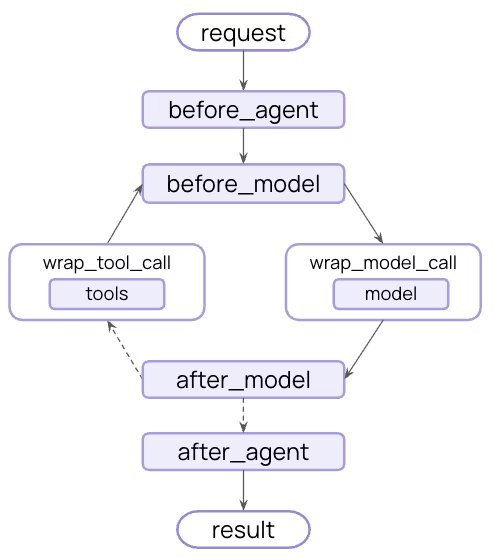



In [ ]:

#? SummarizationMiddleware
from langchain.agents.middleware import SummarizationMiddleware

# 总结
上下文工程是构建一个可靠的Agent系统的重要一环，通过传入正确的上下文可以更好的控制模型输出，更好的完成给定的任务

上下文的类型可以按照可变性分为静态的和动态的，也可以按照生命周期分为运行时和跨对话的；

在Langchain中上下文的类型有：模型上下文、工具上下文、生命周期上下文这三种。、

- 模型上下文指的是调用模型的时候传入的内容，是 transient 瞬时
- 工具上下文控制哪些工具可以访问和产生
- 生命周期上下文控制模型和工具调用之间会发生什么

Langchain中用来实现上下文工程的机制一般是 Middleware ，通过在中间件访问 State、Store、Runtime Context 来达到对上下文的控制

